In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
#  Access my file
df = pd.read_csv('/content/drive/MyDrive/2024/GoogleCloud /DataScience/MD_agric_exam-4313.csv')

df.head(6)

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee
1,5108,663.73390,581.0,-4.7,30.9,5.603219,0.289643,4.2,2.532497,potato
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana
3,5351,594.80370,1748.0,-4.3,33.6,6.477415,0.088777,7.9,4.351564,wheat
4,905,609.49800,1395.8,-4.5,31.3,5.419586,0.050023,10.8,5.034791,cassava
5,2274,270.45100,1665.2,-7.2,34.3,5.873082,0.001545,3.9,1.743458,banana


In [14]:
# print an array of unique crop types
df['Crop_type'].unique()

array(['coffee', 'potato', 'banana', 'wheat', 'cassava', 'maize', 'tea',
       'rice'], dtype=object)

In [13]:
#qn.1 Write code to determine the number of unique crop types in the dataset?
df['Crop_type'].nunique()

8

In [20]:
#qn.2 Identify the maximum annual yield for "wheat" crop type in the dataset (rounded to 2 decimal places).
max_yield = df[df['Crop_type']=='wheat']['Annual_yield'].max()

max_yield_rounded = round(max_yield, 2)
print(f"The maximum annual yield for wheat is: {max_yield_rounded}")


The maximum annual yield for wheat is: 8.99


In [17]:
#qn.2 Identify the maximum annual yield for "wheat" crop type in the dataset (rounded to 2 decimal places).

# since we have loaded our DataFrame into the variable 'df'
# and the columns are named 'Crop_type' and 'Annual_yield'

# Filter data for wheat crop type
wheat_data = df[df['Crop_type'] == 'wheat']

# Get the maximum annual yield and round to 2 decimal places
max_yield = wheat_data['Annual_yield'].max()
max_yield_rounded = round(max_yield, 2)

print(f"The maximum annual yield for wheat is: {max_yield_rounded}")

The maximum annual yield for wheat is: 8.99


In [22]:
#qn.3 Find the total rainfall for crop types where the average pollution level is above 0.2.
filtered_df = df.groupby('Crop_type')['Pollution_level'].mean().pipe(lambda x: df[df['Crop_type'].isin(x[x > 0.2].index)])
total_rainfall = filtered_df['Rainfall'].sum()
print(f"Total rainfall for crop types with average pollution level above 0.2: {total_rainfall}")

Total rainfall for crop types with average pollution level above 0.2: 941959.7


In [23]:
import pandas as pd

# Assuming your DataFrame is loaded into the variable 'df'

# Group data by crop type and calculate average pollution level
crop_pollution = df.groupby('Crop_type')['Pollution_level'].mean()

# Filter crop types with average pollution above 0.2
high_pollution_crops = crop_pollution[crop_pollution > 0.2].index

# Filter original DataFrame for selected crop types and sum rainfall
total_rainfall = df[df['Crop_type'].isin(high_pollution_crops)]['Rainfall'].sum()

print(f"Total rainfall for crop types with average pollution level above 0.2: {total_rainfall}")

Total rainfall for crop types with average pollution level above 0.2: 941959.7


In [27]:
# qn.4 Write a function to calculate the temperature range (Max_temperature_C - Min_temperature_C) for each farmer's field. Then, call the function with the following `Field_ID`: `1458`, `1895`, and `5443`. What are the results of these 3 calls?
def temp_range(x):
  return df[df['Field_ID']==x]['Max_temperature_C']-df[df['Field_ID']==x]['Min_temperature_C']

In [30]:
temp_range(1895)

,0
644,35.7


In [24]:

 # qn.4 Write a function to calculate the temperature range (Max_temperature_C - Min_temperature_C)
 #  for each farmer's field. Then, call the function with the following `Field_ID`: `1458`, `1895`, and `5443`.
 # What are the results of these 3 calls?


def calculate_temperature_range(df, field_id):
  """Calculates the temperature range for a given farmer's field.

  Args:
    df: The pandas DataFrame containing the data.
    field_id: The ID of the farmer's field.

  Returns:
    The temperature range (Max_temperature_C - Min_temperature_C)
    or None if the field_id is not found.
  """
  field_data = df[df['Field_ID'] == field_id]
  if field_data.empty:
    return None  # Handle case where field_id is not found
  else:
    temp_range = field_data['Max_temperature_C'].values[0] - field_data['Min_temperature_C'].values[0]
    return temp_range

# Call the function for the specified Field_IDs
field_ids = [1458, 1895, 5443]
for field_id in field_ids:
  temp_range = calculate_temperature_range(df, field_id)
  print(f"Temperature range for Field_ID {field_id}: {temp_range}")

Temperature range for Field_ID 1458: 40.7
Temperature range for Field_ID 1895: 35.7
Temperature range for Field_ID 5443: 33.4


In [40]:
# 5. What does the following code achieve?

a = df['Crop_type'].unique() # gets all the unique crop types

b = float('inf') #  initializes a variable b with positive infinity
                # This variable will be used to store the lowest average minimum temperature found
c = ''     # nitializes a variable c with an empty string.
        # This variable will store the name of the crop type with the lowest average minimum temperature.

for crop in a:
#Calculates the average minimum temperature (d) for the current crop by:
#Filtering the DataFrame df to select rows where 'Crop_type' matches the current crop.
#Selecting the 'Min_temperature_C' column from the filtered DataFrame.
#Calculating the mean of the selected column."

    d = df[df['Crop_type'] == crop]['Min_temperature_C'].mean()
    if d < b:
      #This condition checks if the calculated average minimum temperature (d) is
      # lower than the current lowest average minimum temperature (b).

        b = d
        # If the condition is true (meaning d is lower),
        # it updates b to store the new lowest average minimum temperature
        c = crop
# It also updates c to store the name of the crop type corresponding
#to the new lowest average minimum temperature.
print(c)
print (round(b, 2)) # lowest average minimum temperature.


# Answer;  Identifies the crop type with the lowest average minimum temperature.

rice
-6.46


In [50]:
# Write code to calculate the total plot size for plots where the pH is less than 5.5.
import pandas as pd

# Assuming your DataFrame is loaded into the variable 'df'

# Filter data for plots with pH less than 5.5
low_ph_plots = df[df['pH'] < 5.5]

# Calculate total plot size for filtered plots
total_plot_size = low_ph_plots['Plot_size'].sum()
total_plot_size_rounded = round(total_plot_size, 2)
print(f"Total plot size for plots with pH less than 5.5: {total_plot_size_rounded}")



Total plot size for plots with pH less than 5.5: 1731.9


df[(df["Min_temperature_C"] < -5 ) & (df["Min_temperature_C"] > 30)]

In [45]:
#7. Using Pandas, create a dataframe that includes entries with a 'Min_temperature_C’< -5 and a 'Max_temperature_C' > 30. How many rows are in the filtered dataset?
df.query("Min_temperature_C < -5 and Max_temperature_C > 30")


,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana
5,2274,270.45100,1665.2,-7.2,34.3,5.873082,0.001545,3.9,1.743458,banana
13,4807,520.29770,292.3,-6.3,32.9,5.379286,0.196589,1.4,0.881568,potato
14,973,432.03570,1464.4,-6.0,30.2,7.482802,0.019800,3.0,1.377434,wheat
...,...,...,...,...,...,...,...,...,...,...
990,1637,504.66306,1144.5,-5.7,32.1,5.666609,0.431891,4.8,2.486276,wheat
991,756,578.91270,889.4,-5.2,31.0,5.062155,0.442495,2.2,1.209928,cassava
992,1332,359.76013,1816.0,-6.4,32.9,7.350705,0.133453,2.9,1.225715,wheat
995,2202,572.95935,625.6,-5.5,31.0,5.258964,0.086330,1.2,0.750675,wheat


In [46]:
# 7. Using Pandas, create a dataframe that includes entries with a 'Min_temperature_C’< -5 and a 'Max_temperature_C' > 30.
# How many rows are in the filtered dataset?
import pandas as pd

# Filter data for specified conditions
filtered_df = df[(df['Min_temperature_C'] < -5) & (df['Max_temperature_C'] > 30)]

# Get the number of rows in the filtered DataFrame
num_rows = len(filtered_df)

print(f"Number of rows in the filtered dataset: {num_rows}")

Number of rows in the filtered dataset: 319


In [49]:
# 8  Using Numpy, calculate the standard deviation of the 'Rainfall' for plots where the 'Plot_size' is larger than the median plot size of the dataset (round to 2 decimal places).

median_plot_size = df['Plot_size'].median()
rainfall_larger_plots = df[df['Plot_size'] > median_plot_size]['Rainfall']
std_rainfall_larger_plots = np.std(rainfall_larger_plots)
rounded_std = round(std_rainfall_larger_plots, 2)
rounded_std

469.62

In [60]:
# 9. If you concatenate the first three digits of the most
#common ‘Max_temperature_C’ with the last three letters of the least common 'Crop_type',
# what string do you get?

# Get the most common Max_temperature_C (first mode if multiple)
most_common_temp = df['Max_temperature_C'].mode()[0]

# Get the least common Crop_type
least_common_crop = df['Crop_type'].value_counts().idxmin()

# Concatenate the first three digits of most_common_temp with
# the last three letters of least_common_crop
result_string = str(most_common_temp)[:3] + least_common_crop[-3:]

print(f"The resulting string is: {result_string}")
# print (most_common_temp)
# print (least_common_crop)

The resulting string is: 30.ice


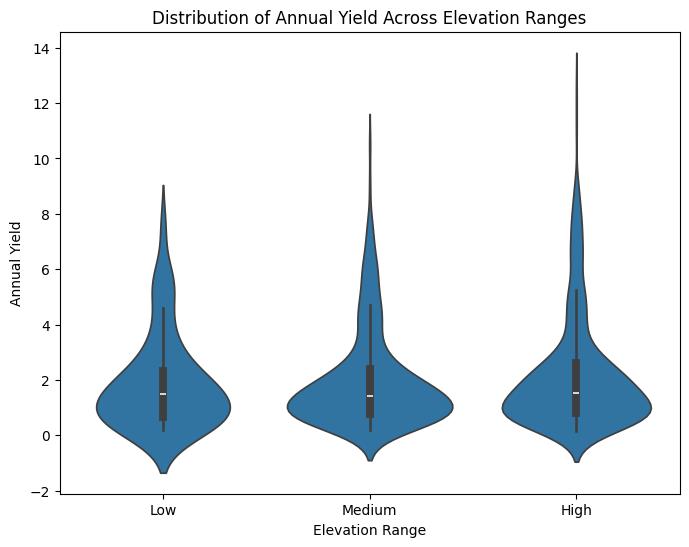

In [ ]:
#: 10. Write Python code to create a violin plot visualising the distribution of 'Annual_yield' across different 'Elevation' ranges.
# Use the provided elevation range categories (Low: < 300m, Medium: 300m - 600m, High: > 600m) to categorise the data before plotting.
# Examine the violin plot displaying the distribution of 'Annual Yield' across three
# elevation categories (Low, Medium, High).
# What insight does the violin plot provide regarding the relationship between elevation ranges
# and annual yield distribution?

# Create elevation categories
df['Elevation_Range'] = pd.cut(df['Elevation'], bins=[-float('inf'), 300, 600, float('inf')],
                              labels=['Low', 'Medium', 'High'])

# Create the violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='Elevation_Range', y='Annual_yield', data=df)
plt.title('Distribution of Annual Yield Across Elevation Ranges')
plt.xlabel('Elevation Range')
plt.ylabel('Annual Yield')
plt.show()


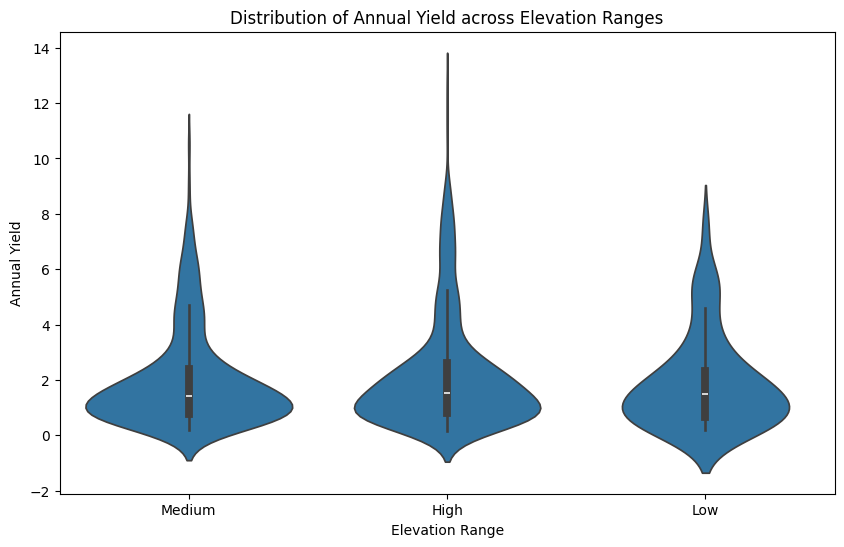


Insight from the Violin Plot:
-----------------------------
The violin plot allows us to compare the distribution of annual yield across different elevation ranges.
We can observe the following:
The Low' elevation category shows a more consistent yield distribution
 with less variability compared to the 'Medium' and 'High' categories. This could indicate
 that lower elevations provide stable conditions for consistent agricultural output.


In [68]:
#: 10. Write Python code to create a violin plot visualising the distribution of 'Annual_yield' across different 'Elevation' ranges.
# Use the provided elevation range categories (Low: < 300m, Medium: 300m - 600m, High: > 600m) to categorise the data before plotting.
# Examine the violin plot displaying the distribution of 'Annual Yield' across three
# elevation categories (Low, Medium, High).
# What insight does the violin plot provide regarding the relationship between elevation ranges
# and annual yield distribution?

# Define elevation range categories
def elevation_category(elevation):
    if elevation < 300:
        return 'Low'
    elif 300 <= elevation <= 600:
        return 'Medium'
    else:
        return 'High'

# Apply the categorization to the DataFrame
df['Elevation_Category'] = df['Elevation'].apply(elevation_category)

# Create the violin plot

plt.figure(figsize=(10, 6))  # Adjust figure size if needed
sns.violinplot(x='Elevation_Category', y='Annual_yield', data=df)
plt.title('Distribution of Annual Yield across Elevation Ranges')
plt.xlabel('Elevation Range')
plt.ylabel('Annual Yield')
plt.show()

# Insight analysis
print("\nInsight from the Violin Plot:")
print("-----------------------------")
print("The violin plot allows us to compare the distribution of annual yield across different elevation ranges.")
print("We can observe the following:")

print("The Low' elevation category shows a more consistent yield distribution"
"\n with less variability compared to the 'Medium' and 'High' categories. This could indicate"
"\n that lower elevations provide stable conditions for consistent agricultural output.")


In [ ]:
#11. Assuming each 'Crop_type' contributes an integer value equal to its length (e.g., 'wheat' contributes 5),
# write a recursive function to sum the integer values for each unique crop type in the datas
def sum_crop_type_lengths(df):
  """
  Recursively sums the length of each unique crop type in the dataset.
  """
  if df.empty:
    return 0

  crop_type = df['Crop_type'].iloc[0]
  length = len(crop_type)
  remaining_df = df[df['Crop_type'] != crop_type]

  return length + sum_crop_type_lengths(remaining_df)

total_sum = sum_crop_type_lengths(df)
total_sum

42

In [64]:
import pandas as pd

def recursive_crop_sum(crop_types, index=0, current_sum=0):
  """Recursively calculates the sum of integer values for crop types.

  Args:
    crop_types: A list of unique crop types.
    index: The current index in the list (starts at 0).
    current_sum: The accumulated sum (starts at 0).

  Returns:
    The total sum of integer values for all crop types.
  """
  if index == len(crop_types):
    return current_sum
  else:
    current_sum += len(crop_types[index])
    return recursive_crop_sum(crop_types, index + 1, current_sum)

# Get unique crop types
unique_crop_types = df['Crop_type'].unique().tolist()

# Calculate the sum using the recursive function
total_sum = recursive_crop_sum(unique_crop_types)

print(f"The sum of integer values for each unique crop type is: {total_sum}")

The sum of integer values for each unique crop type is: 42


In [ ]:
# 12. Write Python code to perform a t-test comparing the average 'Annual_yield'
# between 'coffee' and 'banana' crop types using scipy.stats. What is the p-value,
# rounded to three decimal places?
# 0.125

from scipy import stats

# Assuming your DataFrame is named 'df'

# Separate the 'Annual_yield' data for 'coffee' and 'banana' crop types
coffee_yield = df[df['Crop_type'] == 'coffee']['Annual_yield']
banana_yield = df[df['Crop_type'] == 'banana']['Annual_yield']

# Perform a t-test
t_statistic, p_value = stats.ttest_ind(coffee_yield, banana_yield)

# Round the p-value to three decimal places
rounded_p_value = round(p_value, 3)

rounded_p_value

0.598

In [66]:
# 12. Write Python code to perform a t-test comparing the average 'Annual_yield'
# between 'coffee' and 'banana' crop types using scipy.stats. What is the p-value,
# rounded to three decimal places?
# 0.125
import pandas as pd
from scipy import stats

# Assuming your DataFrame is loaded into the variable 'df'

# Get data for coffee and banana crop types
coffee_yield = df[df['Crop_type'] == 'coffee']['Annual_yield']
banana_yield = df[df['Crop_type'] == 'banana']['Annual_yield']

# Perform t-test
t_statistic, p_value = stats.ttest_ind(coffee_yield, banana_yield)

# Round p-value to three decimal places
p_value_rounded = round(p_value, 3)

print(f"The p-value is: {p_value_rounded}")

The p-value is: 0.598
